<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/_train_1s_30hz_initial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SimCLR Training

In [20]:
# For VSCode
%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

with open('../data_1s_30hz_2class/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../data_1s_30hz_2class/y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('../data_1s_30hz_2class/X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('../data_1s_30hz_2class/y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('../data_1s_30hz_2class/X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('../data_1s_30hz_2class/y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

np_train_data.shape, np_train_labels.shape, np_val_data.shape, np_val_labels.shape, np_test_labels.shape

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


((786, 30, 3), (786, 2), (197, 30, 3), (197, 2), (246, 2))

In [ ]:
# For Google Colab
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys
sys.path.append('../../')
from utils.preprocessing import *



seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load data
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/X_test_data.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz_2class/y_test_onehot.pkl


working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

print(np_train_data.shape, np_train_labels.shape)
print(np_val_data.shape, np_val_labels.shape)

fatal: destination path 'Bachelorarbeit' already exists and is not an empty directory.
--2025-09-30 13:46:47--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1900965 (1.8M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   1.81M  --.-KB/s    in 0.04s   

2025-09-30 13:46:48 (43.8 MB/s) - ‘X_train_normalized.pkl’ saved [1900965/1900965]

--2025-09-30 13:46:48--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s_30hz/TrainTest/y_train_onehot.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 18

## 1.1 Pretraining with SimCLR

In [21]:
# Parameters for all experiments
window_size = 30
input_shape = (window_size, 3)
batch_size = 512
#Number of samples processed together in one training step. Larger batch sizes can speed up training but require more memory.
decay_steps = 1000
#Number of steps after which the learning rate decays (used for learning rate scheduling).
epochs = 200
temperature = 0.1


In [22]:
#A parameter for the SimCLR loss function that controls how sharply similarities are measured.
# transform_funcs = [
#     transformations.scaling_transform_vectorized, # Use Scaling trasnformation
#     transformations.rotation_transform_vectorized # Use rotation trasnformation
# ]
transform_funcs = [
    transformations.time_segment_permutation_transform_improved,
    transformations.channel_shuffle_transform_vectorized
]
#List of data augmentation functions to apply to the input data. Here, only rotation is used.
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function time_segment_permutation_transform_improved at 0x000002D23A831440>
1 <function channel_shuffle_transform_vectorized at 0x000002D23A8313A0>


In [23]:
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')
#Sets TensorFlow to use 32-bit floating point numbers for all computations (standard for deep learning).


In [24]:
# Create a cosine-decayed learning rate schedule and SGD optimizer for training.
lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(lr_decayed_fn)

# Build the base model and attach the SimCLR head for contrastive learning.
base_model = simclr_models.create_base_model_small_dimensions(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

# Train the SimCLR model using the specified transformation function and optimizer.
trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(
    simclr_model,
    np_train_data,
    optimizer,
    batch_size,
    transformation_function,
    temperature=temperature,
    epochs=epochs,
    is_trasnform_function_vectorized=True,
    verbose=1
)

# Save the trained SimCLR model to disk for later use.
simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.hdf5"
trained_simclr_model.save(simclr_model_save_path)

Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

 Non-trainable params: 0 (0.00 B)

epoch: 1 loss: 12.345
epoch: 2 loss: 11.474
epoch: 3 loss: 10.648
epoch: 4 loss: 10.222
epoch: 5 loss: 11.015
epoch: 6 loss: 9.707
epoch: 7 loss: 10.066
epoch: 8 loss: 9.296
epoch: 9 loss: 9.651
epoch: 10 loss: 8.637
epoch: 11 loss: 8.978
epoch: 12 loss: 9.052
epoch: 13 loss: 9.393
epoch: 14 loss: 9.240
epoch: 15 loss: 9.575
epoch: 16 loss: 8.636
epoch: 17 loss: 8.396
epoch: 18 loss: 8.027
epoch: 19 loss: 9.107
epoch: 20 loss: 9.285
epoch: 21 loss: 9.637
epoch: 22 loss: 9.258
epoch: 23 loss: 8.884
epoch: 24 loss: 8.333
epoch: 25 loss: 8.492
epoch: 26 loss: 7.496
epoch: 27 loss: 8.523
epoch: 28 loss: 7.830
epoch: 29 loss: 7.883
epoch: 30 loss: 7.608
epoch: 31 loss: 7.675
epoch: 32 loss: 7.770
epoch: 33 loss: 7.394
epoch: 34 loss: 7.624
epoch: 35 loss: 7.063
epoch: 36 loss: 8.183
epoch: 37 loss: 7.225
epoch: 38 loss: 7.112
epoch: 39 loss: 6.787
epoch: 40 loss: 6.549
epoch: 41 loss: 6.697
epoch: 42 loss: 6.928
epoch: 43 loss: 6.649
epoch: 44 loss: 6.910
epoch: 45 loss: 6.574
epoch: 46 los

epoch: 200 loss: 3.008


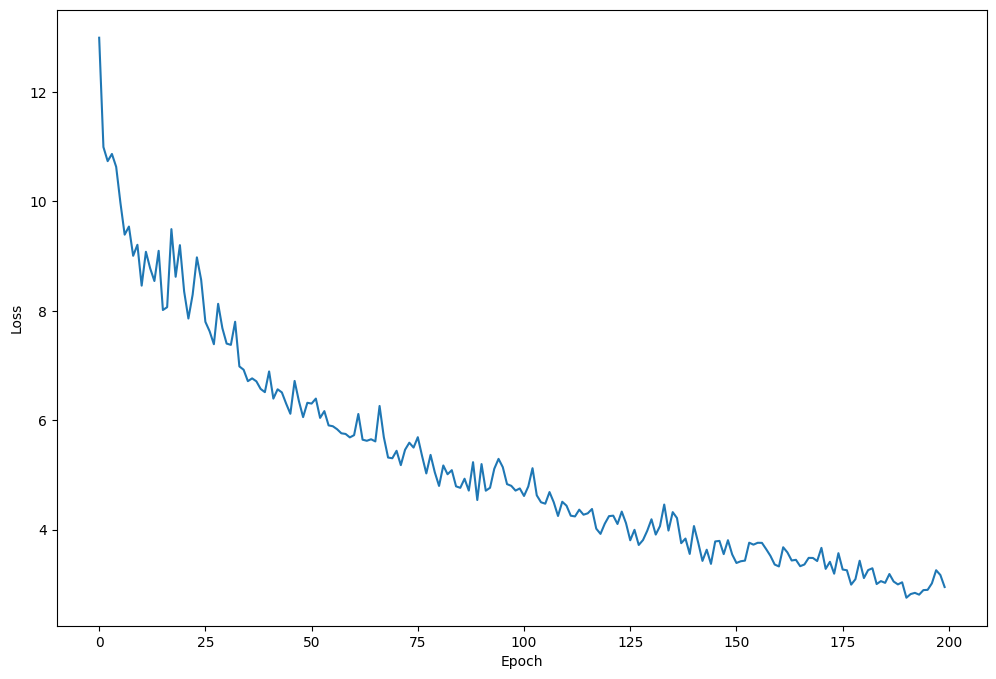

In [6]:
# Plot history of training losses over epochs.
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## 1.2 Fine-tuning and Evaluation

### 1.2.1 Linear Model

#### Train

In [7]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 200
tag = "linear_eval"
output_shape = np_train_labels.shape[1]  # Number of classes for classification

# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - auc: 0.7316 - categorical_accuracy: 0.6388 - loss: 0.5974 - precision: 0.6388 - recall: 0.6388 - val_auc: 0.9686 - val_categorical_accuracy: 0.8985 - val_loss: 0.4419 - val_precision: 0.8985 - val_recall: 0.8985
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - auc: 0.9708 - categorical_accuracy: 0.9015 - loss: 0.4040 - precision: 0.9015 - recall: 0.9015 - val_auc: 0.9659 - val_categorical_accuracy: 0.9036 - val_loss: 0.3780 - val_precision: 0.9036 - val_recall: 0.9036
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - auc: 0.9764 - categorical_accuracy: 0.9162 - loss: 0.3430 - precision: 0.9162 - recall: 0.9162 - val_auc: 0.9645 - val_categorical_accuracy: 0.8985 - val_loss: 0.3434 - val_precision: 0.8985 - val_recall: 0.8985
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - auc: 0.9792 - categorical_accuracy: 0.9212 - loss: 0.3080 - precision: 0.9212 - recall: 0.9212 - val_auc: 0.9656 - val_categorical_accuracy: 0.8985 - val_loss: 0.3210 - v

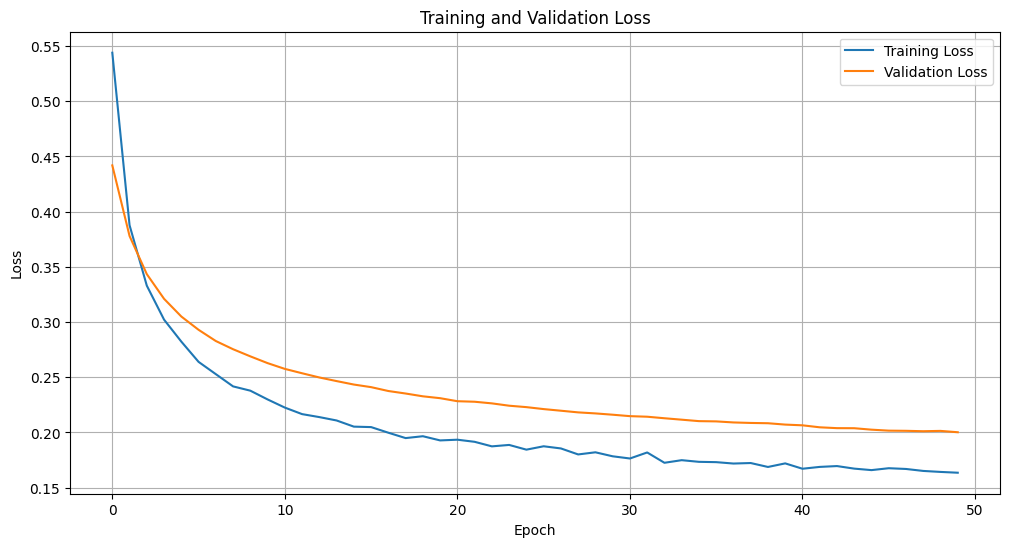

In [8]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

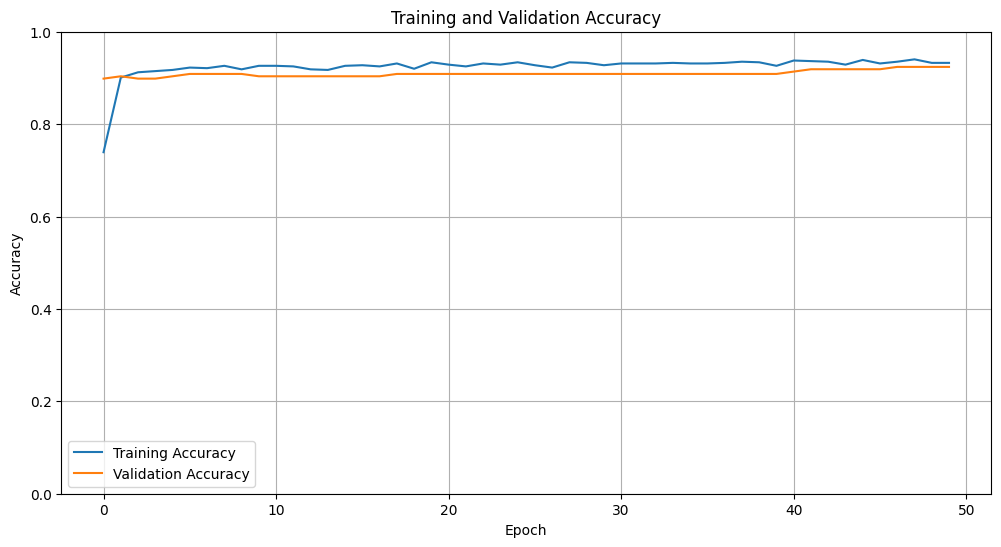

In [9]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [10]:
# Load models and evaluate on test set on vscode
linear_eval_model_path =  linear_eval_best_model_file_name

# Load both models
# simclr_model = tf.keras.models.load_model(simclr_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_eval_model_path)

#### Normalize test data

In [11]:
# You can also use it for test data (but should fit the scaler only on training data)
X_test_normalized = normalize_3d_data(np_test_data)

In [12]:
linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


{'Confusion Matrix': array([[112,  12],
       [  4, 118]]), 'F1 Macro': 0.9349206349206349, 'F1 Micro': 0.9349593495934959, 'F1 Weighted': 0.9349077300296813, 'Precision': 0.936604774535809, 'Recall': 0.9352194606028557, 'Kappa': np.float64(0.8699788583509513)}
Model in last epoch
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
{'Confusion Matrix': array([[112,  12],
       [  4, 118]]), 'F1 Macro': 0.9349206349206349, 'F1 Micro': 0.9349593495934959, 'F1 Weighted': 0.9349077300296813, 'Precision': 0.936604774535809, 'Recall': 0.9352194606028557, 'Kappa': np.float64(0.8699788583509513)}


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


### 1.2.2 Full HAR Model

#### Train

In [13]:
total_epochs = 50
batch_size = 200
tag = "full_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(
    simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"

best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - auc: 0.7460 - categorical_accuracy: 0.6588 - loss: 0.5395 - precision: 0.6588 - recall: 0.6588 - val_auc: 0.9487 - val_categorical_accuracy: 0.8883 - val_loss: 0.2968 - val_precision: 0.8883 - val_recall: 0.8883
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - auc: 0.9744 - categorical_accuracy: 0.9032 - loss: 0.2269 - precision: 0.9032 - recall: 0.9032 - val_auc: 0.9760 - val_categorical_accuracy: 0.9289 - val_loss: 0.2055 - val_precision: 0.9289 - val_recall: 0.9289
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - auc: 0.9838 - categorical_accuracy: 0.9461 - loss: 0.1675 - precision: 0.9461 - recall: 0.9461 - val_auc: 0.9814 - val_categorical_accuracy: 0.9239 - val_loss: 0.1845 - val_precision: 0.9239 - val_recall: 0.9239
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - auc: 0.9871 - categorical_accuracy: 0.9530 - loss: 0.1482 - precision: 0.9530 - recall: 0.9530 - val_auc: 0.9753 - val_categorical_accuracy: 0.9340 - val_loss: 0.2137 - v

#### Plot metrics

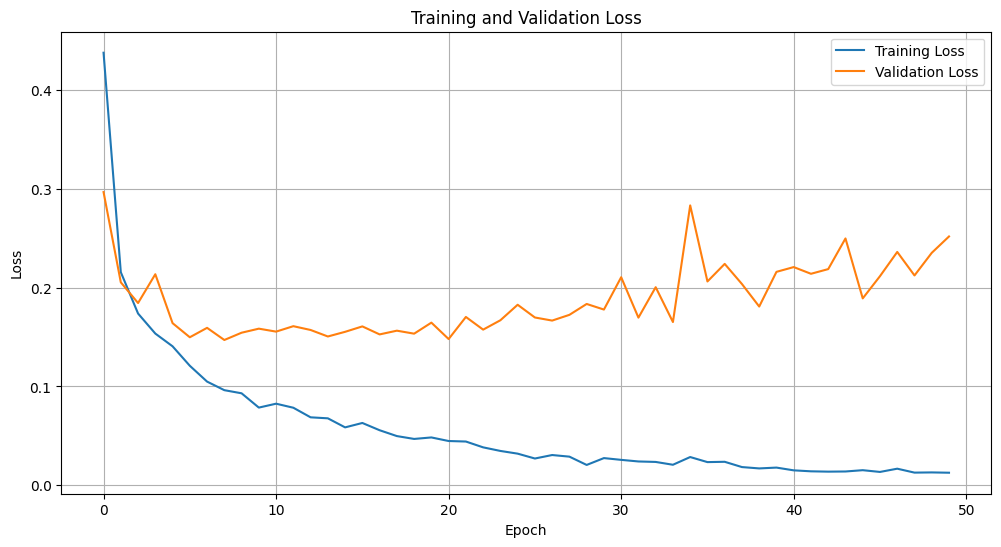

In [14]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

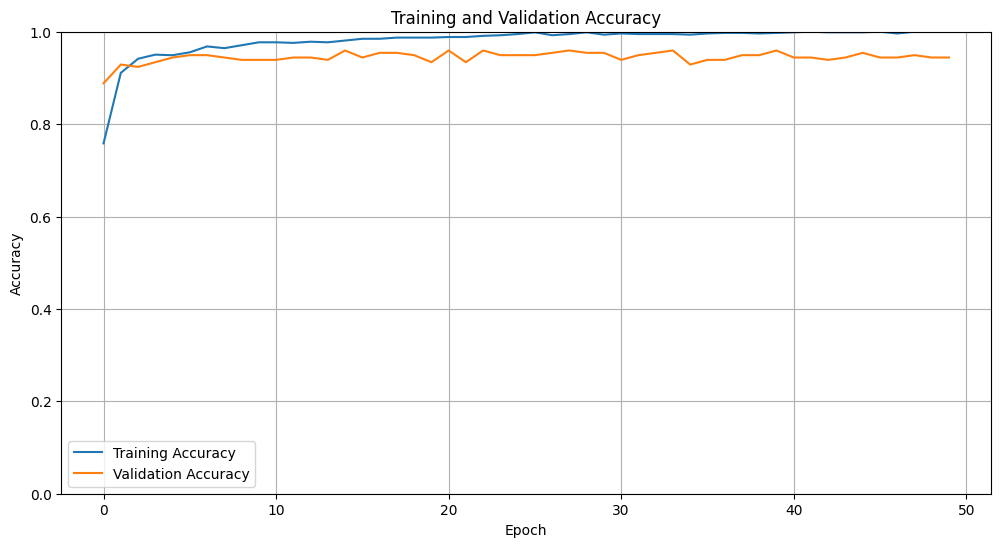

In [15]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [16]:
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
{'Confusion Matrix': array([[112,  12],
       [  3, 119]]), 'F1 Macro': 0.9389749780872212, 'F1 Micro': 0.9390243902439024, 'F1 Weighted': 0.9389608603281693, 'Precision': 0.9411549950215732, 'Recall': 0.9393178212585933, 'Kappa': np.float64(0.8781132324767127)}
Model in last epoch


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
{'Confusion Matrix': array([[117,   7],
       [  2, 120]]), 'F1 Macro': 0.9634091923248549, 'F1 Micro': 0.9634146341463414, 'F1 Weighted': 0.9634055644438639, 'Precision': 0.9640375835373519, 'Recall': 0.9635774722369117, 'Kappa': np.float64(0.9268486090001983)}


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


## Extra: t-SNE Plots

### Parameters

In [17]:
import sklearn.manifold
import seaborn as sns

### t-SNE Representations

In [18]:
# First load the model from the file path
target_model_path = simclr_model_save_path
loaded_model = tf.keras.models.load_model(target_model_path)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(X_test_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 84,416 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(246, 30, 3))
  warnings.warn(msg)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 246 samples in 0.000s...
[t-SNE] Computed neighbors for 246 samples in 0.192s...
[t-SNE] Computed conditional probabilities for sample 246 / 246
[t-SNE] Mean sigma: 2.175118
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.232224
[t-SNE] KL divergence after 1000 iterations: 0.323111


### Plotting

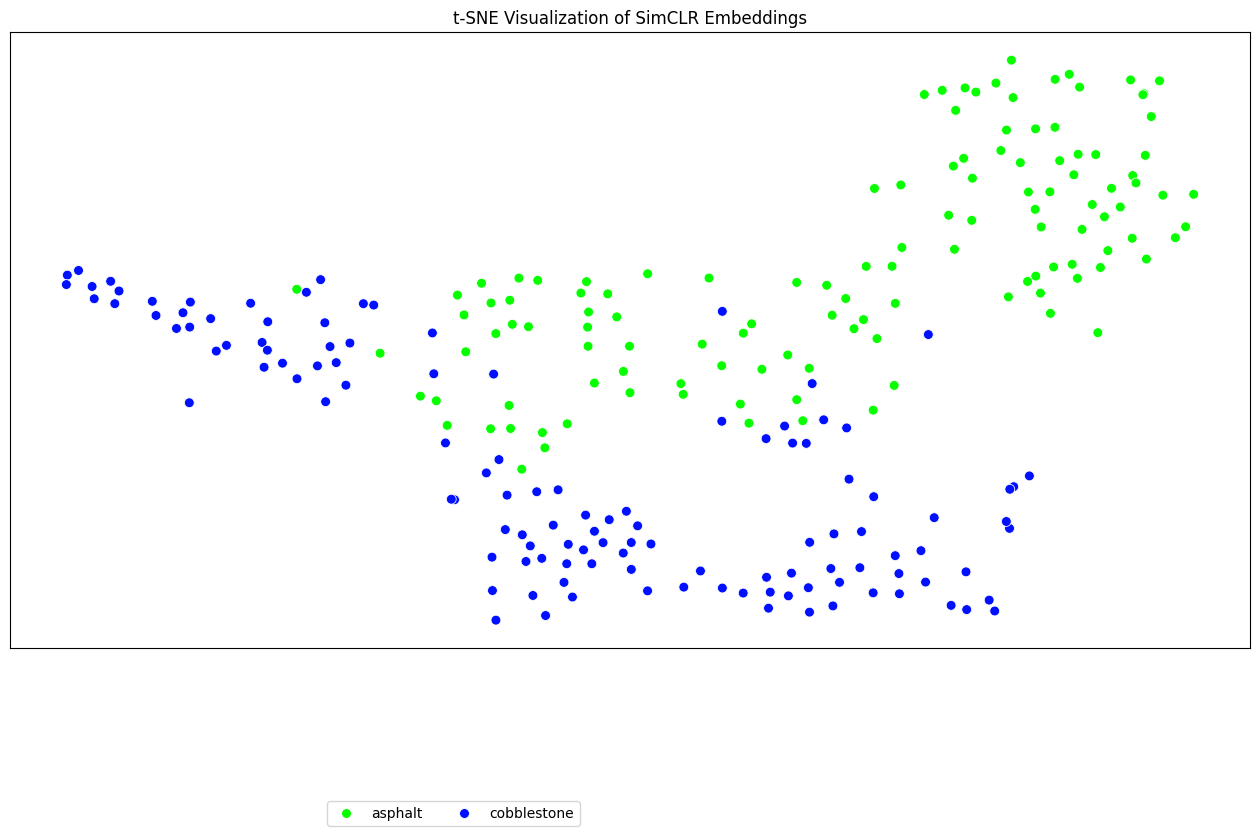

In [ ]:
# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=sns.color_palette("hsv", len(unique_labels)),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# If you have class names, use them for the legend
# Define your activity names if needed
label_list_full_name = ["non_curb", "curb_1"]  # Replace with your actual class names

# Update legend with class names if available
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():  # Check if variable exists
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)